## Кросс-валидация


### Классная работа

In [227]:
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn import svm
from sklearn.datasets import load_iris, load_diabetes, load_wine
from sklearn.model_selection import LeavePOut, cross_val_score, cross_validate, KFold, train_test_split, StratifiedKFold, LeaveOneOut
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, SVR
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, r2_score, mean_squared_error, make_scorer, precision_score, recall_score, confusion_matrix

In [229]:
iris = load_iris()
X=iris.data
y=iris.target

In [231]:
iris_data = pd.DataFrame(iris['data'], columns=iris['feature_names'])

name_map = {0: 'Iris-setosa', 1: 'Iris-versicolor', 2:'Iris-virginica'}
iris_data['class'] = [name_map[k] for k in iris['target']]
iris_data.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
5,5.4,3.9,1.7,0.4,Iris-setosa
6,4.6,3.4,1.4,0.3,Iris-setosa
7,5.0,3.4,1.5,0.2,Iris-setosa
8,4.4,2.9,1.4,0.2,Iris-setosa
9,4.9,3.1,1.5,0.1,Iris-setosa


In [233]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=5)

In [235]:
model = LogisticRegression(solver='liblinear')

In [237]:
model.fit(X_train, y_train)  # Обучение трейновой выборке
y_pred = model.predict(X_test)  # Предсказание для тестовой выборки

In [239]:
print('accuracy: ', accuracy_score(y_test, y_pred))
print('f1: ', f1_score(y_test, y_pred, average='macro'))

accuracy:  0.8260869565217391
f1:  0.8000000000000002


<Axes: >

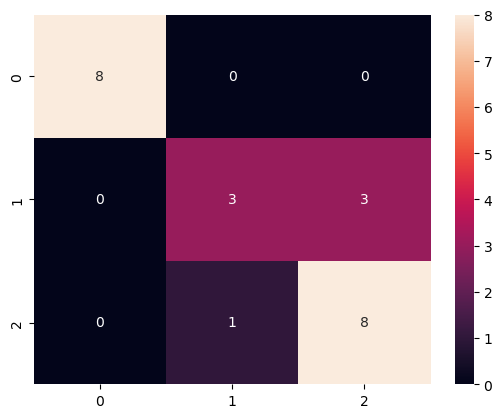

In [241]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True)

In [243]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=0)
model = LogisticRegression()
model.fit(X_train, y_train) #Обучение трейновой выборке
y_pred = model.predict(X_test) #Предсказание для тестовой выборки
print('accuracy: ', accuracy_score(y_test, y_pred))
print('f1: ', f1_score(y_test, y_pred, average='macro'))

accuracy:  1.0
f1:  1.0


<Axes: >

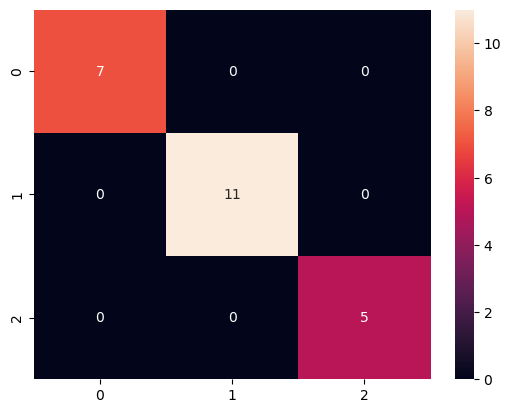

In [245]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True)

**Перекрестная** **проверка**

k-fold разбиение  
*(данные разбиваются на
k(примерно) равных по количеству частей, называемых "блоками", на 𝑘−1 из которых производится обучение, а на 1 валидация.)*

In [249]:
kf = KFold(n_splits = 3,shuffle=True, random_state=15)
kf

KFold(n_splits=3, random_state=15, shuffle=True)

In [251]:
for i, (train_index, test_index) in enumerate(kf.split(y)): #split() - возвращает индексы разбиения
    print("Fold {}: Длинна train: {}, Длинна test: {}".format(i+1, len(train_index), len(test_index)))
    print('Train: index={}\n Test:  index={}'.format(train_index, test_index))

    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

Fold 1: Длинна train: 100, Длинна test: 50
Train: index=[  1   2   3   4   7  10  14  15  16  17  18  19  22  23  24  26  28  29
  32  33  34  35  37  38  39  40  41  42  43  44  45  46  49  50  51  52
  53  54  56  60  62  63  64  65  66  68  69  70  73  75  76  77  79  80
  81  82  83  85  87  88  91  92  93  94  96  99 101 102 104 105 106 107
 108 110 111 113 114 117 118 119 120 121 123 125 128 131 132 133 134 135
 136 137 139 140 141 142 144 145 146 147]
 Test:  index=[  0   5   6   8   9  11  12  13  20  21  25  27  30  31  36  47  48  55
  57  58  59  61  67  71  72  74  78  84  86  89  90  95  97  98 100 103
 109 112 115 116 122 124 126 127 129 130 138 143 148 149]
Fold 2: Длинна train: 100, Длинна test: 50
Train: index=[  0   1   4   5   6   7   8   9  10  11  12  13  15  17  19  20  21  22
  23  24  25  26  27  28  30  31  34  36  37  39  40  41  42  44  47  48
  50  53  55  56  57  58  59  60  61  62  63  65  66  67  70  71  72  74
  75  78  79  84  85  86  89  90  95  96  97

In [253]:
metrics_accuracy = []
metrics_f1 = []
model = LogisticRegression(solver='liblinear')
for i, (train_index, test_index) in enumerate(kf.split(y)):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    metrics_accuracy.append(accuracy_score(y_test, y_pred))
    metrics_f1.append(f1_score(y_test, y_pred, average='macro'))

In [255]:
print('Значения метрики accuracy: {} \nЗначения метрики f1: {}'.format(metrics_accuracy, metrics_f1))

Значения метрики accuracy: [0.96, 0.96, 0.9] 
Значения метрики f1: [0.9595588235294118, 0.9629629629629629, 0.890652557319224]


In [257]:
print("Среднее по кросс-валидации: ", np.array(metrics_f1).mean())

Среднее по кросс-валидации:  0.9377247812705329


In [259]:
print("Дисперсия по кросс-валидации: ", np.array(metrics_f1).var())

Дисперсия по кросс-валидации:  0.0011098284947415997


In [261]:
cv_results = cross_val_score(model,                  # модель
                             X,                      # матрица признаков
                             y,                      # вектор цели
                             cv = kf,                # тип разбиения (можно указать просто число фолдов cv = 3)
                             scoring = 'accuracy',   # метрика
                             n_jobs=-1)              # используются все ядра CPU

print("Кросс-валидация: ", cv_results)
print("Среднее по кросс-валидации: ", cv_results.mean())
print("Дисперсия по кросс-валидации: ", cv_results.std())

Кросс-валидация:  [0.96 0.96 0.9 ]
Среднее по кросс-валидации:  0.94
Дисперсия по кросс-валидации:  0.028284271247461874


Stratified k-Fold *(метод k-Fold, использующий стратификацию при разбиении на фолды: каждый фолд содержит примерно такое же соотношение классов, как и всё исходное множество)*

In [264]:
skf = StratifiedKFold(n_splits=3,shuffle=True, random_state=15)
skf.get_n_splits(X, y)

3

In [266]:
for i, (train_index, test_index) in enumerate(skf.split(X,y)):
    print(f"Fold {i+1}:")
    print('Train: index={}\n Test:  index={}'.format(train_index, test_index))

    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

Fold 1:
Train: index=[  0   1   2   3   4   5   7   8   9  12  14  15  16  17  18  19  21  23
  24  25  26  28  29  31  32  36  37  38  39  40  41  44  45  51  52  53
  54  55  60  61  62  63  65  66  68  70  72  75  77  80  81  82  83  84
  85  86  87  89  90  91  93  94  95  96  97  98 101 102 103 104 105 107
 110 111 112 113 114 116 118 121 122 123 124 126 127 128 129 132 133 134
 139 140 141 142 143 144 145 146 147 149]
 Test:  index=[  6  10  11  13  20  22  27  30  33  34  35  42  43  46  47  48  49  50
  56  57  58  59  64  67  69  71  73  74  76  78  79  88  92  99 100 106
 108 109 115 117 119 120 125 130 131 135 136 137 138 148]
Fold 2:
Train: index=[  0   1   2   4   5   6   9  10  11  13  14  15  16  19  20  21  22  23
  26  27  28  29  30  31  33  34  35  42  43  46  47  48  49  50  51  54
  55  56  57  58  59  61  63  64  66  67  69  70  71  73  74  75  76  78
  79  83  84  87  88  89  90  91  92  94  96  97  99 100 101 103 105 106
 107 108 109 110 114 115 116 117 118 119 

In [268]:
cv_results = cross_val_score(model,                  # модель
                             X,                      # матрица признаков
                             y,                      # вектор цели
                             cv = skf,               # тип разбиения
                             scoring = 'f1_macro',   # метрика
                             n_jobs=-1)              # используются все ядра CPU

print("Кросс-валидация: ", cv_results)
print("Среднее по кросс-валидации: ", cv_results.mean())

Кросс-валидация:  [1.         1.         0.92046784]
Среднее по кросс-валидации:  0.9734892787524366


Leave-one-out  
 *(является частным случаем метода k-Fold: в нём каждый фолд состоит ровно из одного семпла)*

In [271]:
loo = LeaveOneOut()

In [273]:
cv_results = cross_val_score(model,                  # модель
                             X,                      # матрица признаков
                             y,                      # вектор цели
                             cv = loo,               # тип разбиения
                             scoring = 'f1_macro',   # метрика
                             n_jobs=-1)              # используются все ядра CPU

print("Кросс-валидация: ", cv_results)
print("Среднее по кросс-валидации: ", cv_results.mean())

Кросс-валидация:  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 0. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]
Среднее по кросс-валидации:  0.9533333333333334


### Дополнительные задания

#### 1. Изучите разбиение Leave-P-Out. Продемонстрируйте работу этого алгоритма на примере из лабораторной работы.

Leave-P-Out перебирает все возможные комбинации из p наблюдений для теста, остальные – для обучения

In [278]:
iris = load_iris()
X, y = iris.data, iris.target

In [280]:
lpo = LeavePOut(2)  #кол-во элементов для теста

Примеры разбиений LeavePOut(2), первые 3 фолда

In [283]:
for i, (train_idx, test_idx) in enumerate(lpo.split(X)):
    print(f"Fold {i+1}: train indices = {train_idx}, test indices = {test_idx}")
    if i == 2:
        break

Fold 1: train indices = [  2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18  19
  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36  37
  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54  55
  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72  73
  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90  91
  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108 109
 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127
 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144 145
 146 147 148 149], test indices = [0 1]
Fold 2: train indices = [  1   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18  19
  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36  37
  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54  55
  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72  73
  74  75  76  77  78  79  80  81  82

Кросс-валидацию с расчётом метрик accuracy и f1

In [286]:
model = LogisticRegression(solver='liblinear', max_iter=200)

In [288]:
acc_scores = []
f1_scores = []

for train_idx, test_idx in lpo.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc_scores.append(accuracy_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred, average='macro'))

In [290]:
print("Accuracy:", acc_scores[:5])
print("F1-macro:", f1_scores[:5])
print("Средний Accuracy:", np.mean(acc_scores))
print("Средний F1-macro:", np.mean(f1_scores))

Accuracy: [1.0, 1.0, 1.0, 1.0, 1.0]
F1-macro: [1.0, 1.0, 1.0, 1.0, 1.0]
Средний Accuracy: 0.9550335570469799
Средний F1-macro: 0.9405219985085758


In [292]:
cv_acc = cross_val_score(model, X, y, cv=lpo, scoring='accuracy', n_jobs=-1)
cv_f1 = cross_val_score(model, X, y, cv=lpo, scoring='f1_macro', n_jobs=-1)

In [293]:
print("Accuracy:", cv_acc)
print("Средний Accuracy:", cv_acc.mean())
print("F1-macro:", cv_f1)
print("Средний F1-macro:", cv_f1.mean())

Accuracy: [1. 1. 1. ... 1. 1. 1.]
Средний Accuracy: 0.9550335570469799
F1-macro: [1. 1. 1. ... 1. 1. 1.]
Средний F1-macro: 0.9405219985085758


#### 2. Изучите функцию cross_validate(). Продемонстрируйте работу этой функции на тех же данных.

cross_validate позволяет получить не только тестовые, но и обучающие оценки, а также время выполнения. Можно передать несколько метрик сразу

In [298]:
scoring = ['accuracy', 'f1_macro']
model = LogisticRegression(solver='liblinear', max_iter=200)

In [300]:
scores = cross_validate(model, X, y, cv=lpo, scoring=scoring, return_train_score=True)
scores.keys()  # Ключи словаря

dict_keys(['fit_time', 'score_time', 'test_accuracy', 'train_accuracy', 'test_f1_macro', 'train_f1_macro'])

In [301]:
df_scores = pd.DataFrame(scores)
df_scores

,fit_time,score_time,test_accuracy,train_accuracy,test_f1_macro,train_f1_macro
0,0.003001,0.004003,1.0,0.959459,1.0,0.959936
1,0.002000,0.004001,1.0,0.959459,1.0,0.959936
2,0.002000,0.005001,1.0,0.966216,1.0,0.966637
3,0.002000,0.005002,1.0,0.966216,1.0,0.966637
4,0.003000,0.005000,1.0,0.966216,1.0,0.966637
...,...,...,...,...,...,...
11170,0.002001,0.004002,1.0,0.966216,1.0,0.965983
11171,0.002001,0.003001,1.0,0.966216,1.0,0.965983
11172,0.002000,0.003000,1.0,0.966216,1.0,0.965983
11173,0.002000,0.003001,1.0,0.966216,1.0,0.965983


In [302]:
scores['test_accuracy']

array([1., 1., 1., ..., 1., 1., 1.])

In [303]:
print("Средний test_accuracy:", scores['test_accuracy'].mean())
print("Средний test_f1_macro:", scores['test_f1_macro'].mean())

Средний test_accuracy: 0.9550335570469799
Средний test_f1_macro: 0.9405219985085758


#### 3. Оцените при помощи кросс-валидации другие метрики эффективности для этой же модели.

In [309]:
scoring = ['precision_macro', 'recall_macro']
model = LogisticRegression(solver='liblinear', max_iter=200)

In [311]:
scores = cross_validate(model2, X, y, scoring=scoring)
sorted(scores.keys())

['fit_time', 'score_time', 'test_precision_macro', 'test_recall_macro']

In [313]:
df = pd.DataFrame(scores)
df

,fit_time,score_time,test_precision_macro,test_recall_macro
0,0.002003,0.005000,1.000000,1.000000
1,0.001000,0.005002,0.969697,0.966667
2,0.000988,0.004999,0.933333,0.933333
3,0.001000,0.005002,0.923077,0.900000
4,0.002000,0.005001,1.000000,1.000000


In [315]:
scores['test_precision_macro']

array([1.        , 0.96969697, 0.93333333, 0.92307692, 1.        ])

In [317]:
scores['test_recall_macro']

array([1.        , 0.96666667, 0.93333333, 0.9       , 1.        ])

In [319]:
print("Средний precision_macro:", scores['test_precision_macro'].mean())
print("Средний recall_macro:", scores['test_recall_macro'].mean())

Средний precision_macro: 0.9652214452214452
Средний recall_macro: 0.96


#### 4. Сравните кросс-валидированные результаты работы нескольких моделей на одних и тех же данных.

In [322]:
models = {
    'LogisticRegression': LogisticRegression(solver='liblinear', max_iter=200),
    'SVC (linear)': SVC(kernel='linear', random_state=0),
    'MLPClassifier': MLPClassifier(random_state=0, max_iter=500)
}

In [324]:
scoring = ['accuracy', 'f1_macro']
res = {}

In [326]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    #scores = cross_validate(model, X, y, cv=lpo, scoring=scoring, n_jobs=-1)  # огромное число фолдов C(150,2) = 11 175
    scores = cross_validate(model, X, y, cv=kf, scoring=scoring, n_jobs=-1)
    res[name] = {
        'mean_accuracy': scores['test_accuracy'].mean(),
        'std_accuracy': scores['test_accuracy'].std(),
        'mean_f1': scores['test_f1_macro'].mean(),
        'std_f1': scores['test_f1_macro'].std()
    }

In [328]:
df_comparison = pd.DataFrame(res).T
df_comparison

,mean_accuracy,std_accuracy,mean_f1,std_f1
LogisticRegression,0.960000,0.024944,0.957472,0.029771
SVC (linear),0.973333,0.024944,0.974237,0.023792
MLPClassifier,0.973333,0.024944,0.971731,0.024644


#### 5. Повторите анализ на другом датасете: встроенном наборе данных о диабете.

In [331]:
diabetes = load_diabetes()
X_diab, y_diab = diabetes.data, diabetes.target

In [333]:
X_train, X_test, y_train, y_test = train_test_split(X_diab, y_diab, test_size=0.15, random_state=0)

In [335]:
model_svr = SVR()
model_svr.fit(X_train, y_train)

y_pred = model_svr.predict(X_test)

In [337]:
print("R2:", r2_score(y_test, y_pred))  # на тестовой
print("MSE:", mean_squared_error(y_test, y_pred))

R2: 0.06584215312739616
MSE: 4465.8309656323645


In [339]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [341]:
r2_scores = []
mse_scores = []

for train_idx, test_idx in kf.split(X_diab):
    X_tr, X_te = X_diab[train_idx], X_diab[test_idx]
    y_tr, y_te = y_diab[train_idx], y_diab[test_idx]
    
    model_svr.fit(X_tr, y_tr)
    y_pr = model_svr.predict(X_te)
    
    r2_scores.append(r2_score(y_te, y_pr))
    mse_scores.append(mean_squared_error(y_te, y_pr))

In [343]:
print("R2 на фолдах:", r2_scores)
print("MSE на фолдах:", mse_scores)
print("Средний R2:", np.mean(r2_scores))
print("Средний MSE:", np.mean(mse_scores))

R2 на фолдах: [0.18211365770500287, 0.10588505139813886, 0.11103009960479515, 0.1575300444553852, 0.19091043397162122]
MSE на фолдах: [4333.285954518086, 5578.03402942788, 4838.59968640031, 5670.122190964748, 4520.853145417193]
Средний R2: 0.14949385742698867
Средний MSE: 4988.179001345643


In [345]:
cv_r2 = cross_val_score(model_svr, X_diab, y_diab, cv=kf, scoring='r2')

In [347]:
print("cross_val_score R2:", cv_r2)
print("Средний R2:", cv_r2.mean())

cross_val_score R2: [0.18211366 0.10588505 0.1110301  0.15753004 0.19091043]
Средний R2: 0.14949385742698867


In [349]:
scoring = ['r2', 'neg_mean_squared_error']
cv_results = cross_validate(model_svr, X_diab, y_diab, cv=kf, scoring=scoring)

In [351]:
print("R2 на фолдах:", cv_results['test_r2'])
print("Отрицательный MSE:", cv_results['test_neg_mean_squared_error'])
print("Средний R2:", cv_results['test_r2'].mean())
print("Средний MSE:", -cv_results['test_neg_mean_squared_error'].mean())  # минус, для полож. MSE

R2 на фолдах: [0.18211366 0.10588505 0.1110301  0.15753004 0.19091043]
Отрицательный MSE: [-4333.28595452 -5578.03402943 -4838.5996864  -5670.12219096
 -4520.85314542]
Средний R2: 0.14949385742698867
Средний MSE: 4988.179001345643


In [353]:
df = pd.DataFrame(scores)
df

,fit_time,score_time,test_accuracy,test_f1_macro
0,0.475125,0.004001,1.000000,1.000000
1,0.474107,0.004002,0.966667,0.958486
2,0.415097,0.006001,0.966667,0.962848
3,0.447120,0.004001,0.933333,0.937322
4,0.418096,0.006002,1.000000,1.000000


#### 6. Сделайте k-блочную перекрёстную проверку (KFold) модели логистической регрессии, предварительно стандартизировав данные. Для этого создайте конвейер с помощью make_pipeline из библиотеки sklearn.pipeline, который будет стандартизировать, а затем выполнять логистическую регрессию

In [356]:
wine = load_wine()
X_wine, y_wine = wine.data, wine.target
#print(wine.DESCR)

In [358]:
pipeline = make_pipeline(StandardScaler(), LogisticRegression(max_iter=200))

In [360]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [362]:
cv_scores = cross_val_score(pipeline, X_wine, y_wine, cv=kf, scoring='f1_macro', n_jobs=-1)

In [364]:
print("Кросс-валидация KFold (f1_macro):", cv_scores)
print("Средний f1_macro:", cv_scores.mean())
print("Стандартное отклонение (дисперсия):", cv_scores.std())

Кросс-валидация KFold (f1_macro): [1.         0.97217391 1.         0.97079365 1.        ]
Средний f1_macro: 0.9885935127674259
Стандартное отклонение (дисперсия): 0.013976853682719389


In [366]:
for i, score in enumerate(cv_scores):
    print(f"Fold {i+1}: f1_macro = {score:.4f}")

Fold 1: f1_macro = 1.0000
Fold 2: f1_macro = 0.9722
Fold 3: f1_macro = 1.0000
Fold 4: f1_macro = 0.9708
Fold 5: f1_macro = 1.0000
